Polynomial degree: 1
Training MSE: 42.90
Polynomial degree: 2
Training MSE: 20.44
Polynomial degree: 10
Training MSE: 18.26


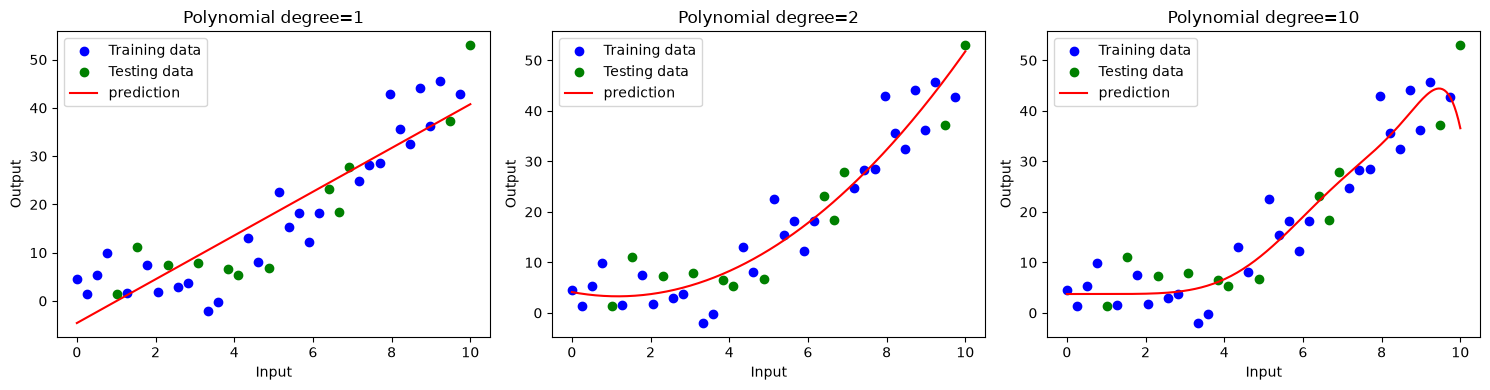

Testing MSE: 38.42



In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

#generate reproducable nonlinear data
np.random.seed(42)

X=np.linspace(0,10,40).reshape(-1,1)

#np.random.normal(0,5,40) is to generate random noise
#this adds the reliastic variation to the output data
#np.random.normal(mean,std,no_of_values)
y=2+0.5*X[:,0]**2+np.random.normal(0,5,40)#y=2+0.5x**2 is the poly fn

#Divide the data
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.30,random_state=42
)

degrees=[1,2,10]
#include_bias=False is to tell Poly...features not to create an additional constant col containing only 1s
for degree in degrees:
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )

    model.fit(X_train,y_train)

    train_prediction=model.predict(X_train)
    test_prediction=model.predict(X_test)

    train_mse=mean_squared_error(y_train,train_prediction)
    test_mse=mean_squared_error(y_test,test_prediction)

    print(f"Polynomial degree: {degree}")
    print(f"Training MSE: {train_mse:.2f}")
    X_plot = np.linspace(0,10,200).reshape(-1,1)
plt.figure(figsize=(15,4))

for index,degree in enumerate(degrees):
    model=make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    model.fit(X_train,y_train)
    y_plot=model.predict(X_plot)

    plt.subplot(1,3,index+1)
    plt.scatter(X_train,y_train,color="blue",label="Training data")
    plt.scatter(X_test,y_test,color="green",label="Testing data")
    plt.plot(X_plot,y_plot,color="red",label="prediction")

    plt.title(f"Polynomial degree={degree}")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.legend()
plt.tight_layout()
plt.show()
print(f"Testing MSE: {test_mse:.2f}")
print()

In [7]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

for degree in range(1,11):
    model=make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    scores=cross_val_score(model,X,y,cv=5,scoring="neg_mean_squared_error")

    mean_mse=-scores.mean()
    print(f"Degree {degree}: CV MSE={mean_mse:.2f}")

Degree 1: CV MSE=110.69
Degree 2: CV MSE=44.22
Degree 3: CV MSE=71.23
Degree 4: CV MSE=82.46
Degree 5: CV MSE=1346.32
Degree 6: CV MSE=7930.95
Degree 7: CV MSE=20375.98
Degree 8: CV MSE=31567.34
Degree 9: CV MSE=55109.01
Degree 10: CV MSE=67544.63
